In [7]:
import pandas as pd

# Load the dataset into a DataFrame (think of it as a Python spreadsheet)
df = pd.read_csv('../data/telco_customer_data.csv')

# Look at the first 5 rows of the data
df.head()

SystemError: <class 'pandas._libs.tslib.__pyx_defaults'> returned a result with an exception set

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.shape

(7043, 21)

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
# Convert Churn column text to numbers: Yes -> 1, No -> 0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Check the first few rows of the Churn column to see if it worked
df['Churn'].head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [8]:
# Select only our features (X) and drop columns we don't need for prediction
# We drop 'customerID' because a random ID string has no effect on loyalty.
X = df.drop(columns=['customerID', 'Churn'])

# Convert all text columns in X into numbers automatically
X = pd.get_dummies(X, drop_first=True)

# Our target variable (Y) is what we want to predict
y = df['Churn']

# Look at the new numerical columns we created
X.head()

,SeniorCitizen,tenure,MonthlyCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,...,TotalCharges_8496.7,TotalCharges_8529.5,TotalCharges_8543.25,TotalCharges_8547.15,TotalCharges_8564.75,TotalCharges_8594.4,TotalCharges_8670.1,TotalCharges_8672.45,TotalCharges_8684.8,TotalCharges_
0,0,1,29.85,False,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0,34,56.95,True,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0,2,53.85,True,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,0,45,42.30,True,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,0,2,70.70,False,False,False,True,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [9]:
from sklearn.model_selection import train_test_split

# Split the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the sizes of our splits
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 5634
Testing samples: 1409


In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 1. Initialize the Decision Tree model
# We set max_depth=5 so the tree doesn't grow too massive and complicated
model = DecisionTreeClassifier(max_depth=5, random_state=42)

# 2. Train the model using our training data
model.fit(X_train, y_train)

# 3. Make predictions on the hidden testing data
y_pred = model.predict(X_test)

# 4. Calculate how accurate the model's predictions are
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 80.77%


C:\Users\Ishika\AppData\Local\Temp\ipykernel_18204\1047546517.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_imp.head(5), y=feature_imp.head(5).index, palette='viridis')


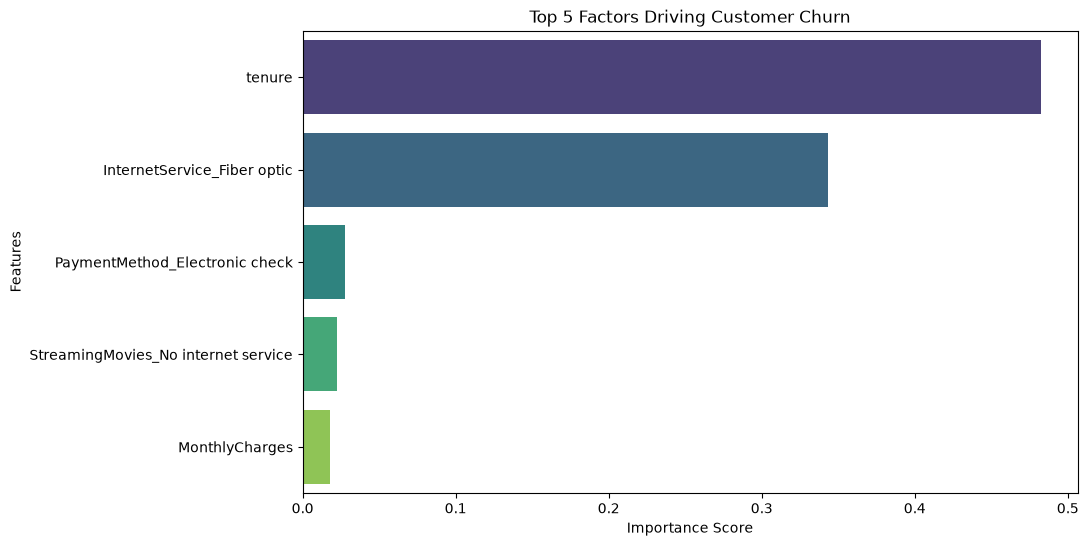

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the importance values from our trained model
importances = model.feature_importances_

# Pair them up with the column names and sort them
feature_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

# Create a beautiful bar chart of the top 5 most important clues
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_imp.head(5), y=feature_imp.head(5).index, palette='viridis')
plt.title('Top 5 Factors Driving Customer Churn')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()